In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

### Run this code to verify if wandb is working.

In [1]:
import wandb
import os
from kaggle_secrets import UserSecretsClient

# fetch the key from Kaggle secrets and authenticate
secret  = UserSecretsClient()
api_key = secret.get_secret("WANDB_API_KEY")
wandb.login(key=api_key)

# quick test run
run = wandb.init(project="lpd-radar-thesis", name="setup-test", mode="online")
wandb.log({"test_value": 1.0})
wandb.finish()

print("W&B setup complete ✓")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: venuworkspace (venuworkspace-rajiv-gandhi-institute-of-petroleum-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


test_value,▁
test_value,1


W&B setup complete ✓


# 05 — GAN Training

This notebook implements the cWGAN-GP training loop from
Ziemann & Metzler (2024), Section IV.

**Two-phase training schedule (matches the paper):**
- **Phase 1** — train GAN to convergence with cWGAN-GP loss only.
  The generator learns to match the RF background distribution.
- **Phase 2** — fine-tune with cWGAN-GP loss + ambiguity loss.
  The generator learns to also produce good radar waveforms.

**Key training details from the paper:**
- 5 critic updates per 1 generator update
- Generator optimiser: Adam, lr = 1e-5
- Critic optimiser: RMSProp, lr = 5e-5
- Batch size: 512
- Gradient penalty coefficient λ = 10
- Ambiguity loss weight η: swept over [1e-5, 1e-1]

## 1. Setup

In [1]:
import os
import sys
import time
import numpy as np
import torch
import torch.nn as nn
import wandb
from kaggle_secrets import UserSecretsClient
import shutil

# ── pull latest src modules from GitHub ──────────────────────────────────────
REPO    = "glitching-gops/lpd-radar-waveform"
BRANCH  = "main"
BASE    = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/src"
SRC_DIR = "/kaggle/working/src"

os.makedirs(SRC_DIR, exist_ok=True)

for fname in ["__init__.py", "dataset.py", "models.py", "ambiguity.py"]:
    ret = os.system(f"wget -q -O {SRC_DIR}/{fname} {BASE}/{fname}")
    status = "✓" if ret == 0 else "✗ FAILED"
    print(f"  {fname:<15} {status}")

sys.path.insert(0, "/kaggle/working")

from src.dataset   import get_loaders, MODULATIONS, SNR_VALUES
from src.models    import Generator, Critic
from src.ambiguity import AmbiguityLoss

print("\nAll modules ready ✓")

  __init__.py     ✓
  dataset.py      ✓
  models.py       ✓
  ambiguity.py    ✓

All modules ready ✓


In [2]:
import torch

# ── device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

# ── dataset path ──────────────────────────────────────────────────────────────
HDF5_PATH = None
for dirpath, _, filenames in os.walk("/kaggle/input"):
    for fname in filenames:
        if fname.endswith(".hdf5") or fname.endswith(".h5"):
            HDF5_PATH = os.path.join(dirpath, fname)

assert HDF5_PATH is not None, "HDF5 file not found under /kaggle/input"
print(f"Dataset : {HDF5_PATH}")

# ── output directory ──────────────────────────────────────────────────────────
CKPT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Checkpoints : {CKPT_DIR}")

Device : cuda:0
Dataset : /kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5
Checkpoints : /kaggle/working/checkpoints


## 2. Hyperparameters

All training hyperparameters are defined in one place so they are
easy to find, change, and log to W&B.

In [3]:
# ── phase 1: GAN-only training ────────────────────────────────────────────────
P1 = dict(
    phase          = 1,
    n_epochs       = 40,       # train until Wasserstein loss plateaus
    batch_size     = 512,
    lr_G           = 1e-5,      # Adam  (paper)
    lr_C           = 5e-5,      # RMSProp (paper)
    n_critic       = 2,         # critic steps per generator step (paper)
    lambda_gp      = 10,        # gradient penalty coefficient (paper)
    latent_dim     = 512,
    eta            = 0.0,       # no ambiguity loss in phase 1
)

# ── phase 2: fine-tuning with ambiguity loss ──────────────────────────────────
P2 = dict(
    phase          = 2,
    n_epochs       = 10,        # paper: small number of fine-tune epochs
    batch_size     = 512,
    lr_G           = 1e-5,
    lr_C           = 5e-5,
    n_critic       = 2,
    lambda_gp      = 10,
    latent_dim     = 512,
    eta            = 1e-4,      # ambiguity loss weight — sweep this later
    n_doppler      = 256,       # paper value
    target_peak    = 1000.0,    # chi (paper)
    zero_doppler_w = 1000.0,    # gamma (paper)
    n_delays       = 128,       # delay bins for sidelobe loss
)

print("Phase 1 config:", P1)
print("\nPhase 2 config:", P2)

Phase 1 config: {'phase': 1, 'n_epochs': 40, 'batch_size': 512, 'lr_G': 1e-05, 'lr_C': 5e-05, 'n_critic': 2, 'lambda_gp': 10, 'latent_dim': 512, 'eta': 0.0}

Phase 2 config: {'phase': 2, 'n_epochs': 10, 'batch_size': 512, 'lr_G': 1e-05, 'lr_C': 5e-05, 'n_critic': 2, 'lambda_gp': 10, 'latent_dim': 512, 'eta': 0.0001, 'n_doppler': 256, 'target_peak': 1000.0, 'zero_doppler_w': 1000.0, 'n_delays': 128}


## 3. W&B initialisation

We log all hyperparameters, losses, and generated waveform samples
to Weights & Biases. This gives us a complete record of every run
that we can compare later during gap analysis.

In [4]:
def init_wandb(config: dict, run_name: str) -> None:
    """Initialise a W&B run with the given config."""
    secret  = UserSecretsClient()
    api_key = secret.get_secret("WANDB_API_KEY")
    wandb.login(key=api_key, relogin=False)

    wandb.init(
        project = "lpd-radar-thesis",
        name    = run_name,
        config  = config,
        reinit  = True,
    )
    print(f"W&B run: {wandb.run.name}  |  {wandb.run.url}")

## 4. Data loaders

In [5]:
print("Building data loaders...")
loader_gen, loader_det, meta = get_loaders(HDF5_PATH, batch_size=P1["batch_size"])
print(f"Generator loader : {len(loader_gen):,} batches/epoch")
print(f"Detector  loader : {len(loader_det):,} batches/epoch")

Building data loaders...
Caching 319,488 samples into RAM...
  50,000 / 319,488
  250,000 / 319,488
Cached 319,488 samples in 53s  (2.6 GB RAM)
Caching 319,488 samples into RAM...
  50,000 / 319,488
  250,000 / 319,488
Cached 319,488 samples in 52s  (2.6 GB RAM)
Generator loader : 624 batches/epoch
Detector  loader : 624 batches/epoch


## 5. The cWGAN-GP loss

The Wasserstein GAN with gradient penalty optimises:

$$\mathcal{L}_W = \underbrace{\mathbb{E}[D(\tilde{x}|y)]}_{\text{fake score}} - \underbrace{\mathbb{E}[D(x|y)]}_{\text{real score}} + \lambda \underbrace{\mathbb{E}\left[(\|\nabla_{\hat{x}} D(\hat{x}|y)\|_2 - 1)^2\right]}_{\text{gradient penalty}}$$

**Critic** maximises the gap between real and fake scores (wants real
scores high, fake scores low).

**Generator** minimises the fake score (wants the critic to score its
outputs high — i.e. indistinguishable from real).

**Gradient penalty** enforces the 1-Lipschitz constraint on the critic
by penalising gradient norms that deviate from 1. It is computed on
interpolated samples $\hat{x} = \epsilon x + (1-\epsilon)\tilde{x}$
where $\epsilon \sim U(0,1)$.

The critic is trained 5× per generator step to ensure it provides
accurate gradient information before the generator updates.

In [6]:
def gradient_penalty(critic:   nn.Module,
                     x_real:   torch.Tensor,
                     x_fake:   torch.Tensor,
                     y:        torch.Tensor,
                     lambda_gp: float) -> torch.Tensor:
    """
    Compute WGAN-GP gradient penalty.

    Interpolates between real and fake samples, evaluates the critic,
    and penalises gradient norms that deviate from 1.

    Parameters
    ----------
    critic    : the critic network
    x_real    : (B, 2, N)  real background samples
    x_fake    : (B, 2, N)  generated samples (detached)
    y         : (B, 2, N)  conditioning signal
    lambda_gp : float      penalty coefficient (paper uses 10)

    Returns
    -------
    gp : scalar tensor
    """
    B = x_real.size(0)

    # random interpolation coefficients — one per sample
    alpha   = torch.rand(B, 1, 1, device=x_real.device)
    x_hat   = (alpha * x_real + (1 - alpha) * x_fake).requires_grad_(True)

    score_hat = critic(x_hat, y)

    gradients = torch.autograd.grad(
        outputs      = score_hat,
        inputs       = x_hat,
        grad_outputs = torch.ones_like(score_hat),
        create_graph = True,    # needed to differentiate through the penalty
        retain_graph = True,
    )[0]                                               # (B, 2, N)

    grad_norm = gradients.view(B, -1).norm(2, dim=1)  # (B,)
    gp        = lambda_gp * ((grad_norm - 1) ** 2).mean()

    return gp

## 6. Training functions

We separate the critic step and generator step into clean functions.
This makes the main training loop readable and easy to debug.

**Critic step:**
1. Score a batch of real samples
2. Generate a batch of fake samples
3. Score the fake samples
4. Compute Wasserstein loss + gradient penalty
5. Update critic weights

**Generator step:**
1. Generate a batch of fake samples
2. Score them with the (frozen) critic
3. Compute generator loss (negative critic score)
4. Optionally add ambiguity loss (Phase 2 only)
5. Update generator weights

In [7]:
def critic_step(G, C, opt_C, x_real, y, cfg):
    """One critic update. Returns dict of loss components."""
    B = x_real.size(0)

    # sample latent vector
    z = torch.randn(B, cfg["latent_dim"], 1, device=x_real.device)

    # generate fake samples — detach so gradients don't flow to G
    with torch.no_grad():
        x_fake = G(z, y)

    # critic scores
    score_real = C(x_real, y)
    score_fake = C(x_fake, y)

    # Wasserstein distance estimate (we want to maximise this in the critic)
    w_dist = score_real.mean() - score_fake.mean()

    # gradient penalty
    gp = gradient_penalty(C, x_real, x_fake.detach(), y, cfg["lambda_gp"])

    # critic loss = -Wasserstein + GP  (we minimise, so negate W-dist)
    loss_C = -w_dist + gp

    opt_C.zero_grad()
    loss_C.backward()
    opt_C.step()

    return {
        "loss_C":      loss_C.item(),
        "w_dist":      w_dist.item(),
        "gp":          gp.item(),
        "score_real":  score_real.mean().item(),
        "score_fake":  score_fake.mean().item(),
    }


def generator_step(G, C, opt_G, y, cfg, ambiguity_fn=None):
    """One generator update. Returns dict of loss components."""
    B = y.size(0)
    z = torch.randn(B, cfg["latent_dim"], 1, device=y.device)

    x_fake     = G(z, y)
    score_fake = C(x_fake, y)

    # generator wants the critic to score its outputs highly
    loss_G = -score_fake.mean()

    # phase 2: add ambiguity loss
    loss_ambig = torch.tensor(0.0, device=y.device)
    if ambiguity_fn is not None and cfg["eta"] > 0:
        loss_ambig = ambiguity_fn(x_fake)
        loss_G     = loss_G + cfg["eta"] * loss_ambig

    opt_G.zero_grad()
    loss_G.backward()
    opt_G.step()

    return {
        "loss_G":      loss_G.item(),
        "loss_ambig":  loss_ambig.item(),
    }

## 7. Checkpoint utilities

We save checkpoints at the end of every epoch so training can be
resumed if the Kaggle session times out. We also save the best
checkpoint based on Wasserstein distance.

In [10]:
def save_checkpoint(G, C, opt_G, opt_C, epoch, metrics, tag, ckpt_dir):
    """Save generator, critic, and optimiser states."""
    path = os.path.join(ckpt_dir, f"ckpt_{tag}_epoch{epoch:04d}.pt")
    # convert any numpy values in metrics to Python floats
    metrics_clean = {k: float(v) for k, v in metrics.items()}
    torch.save({
        "epoch":   int(epoch),
        "metrics": metrics_clean,
        "G":       G.state_dict(),
        "C":       C.state_dict(),
        "opt_G":   opt_G.state_dict(),
        "opt_C":   opt_C.state_dict(),
    }, path)
    return path


def load_checkpoint(path, G, C, opt_G=None, opt_C=None):
    """Load checkpoint. Optimisers are optional (skip for inference)."""
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    G.load_state_dict(ckpt["G"])
    C.load_state_dict(ckpt["C"])
    if opt_G is not None:
        opt_G.load_state_dict(ckpt["opt_G"])
    if opt_C is not None:
        opt_C.load_state_dict(ckpt["opt_C"])
    print(f"Loaded checkpoint: {path}  (epoch {ckpt['epoch']})")
    return ckpt["epoch"], ckpt["metrics"]

## 8. Main training loop

The loop follows the paper's training procedure exactly:
- For each epoch, iterate over the generator split
- Every batch: run `n_critic` critic steps, then 1 generator step
- Log losses to W&B every 50 steps
- Save a checkpoint every epoch
- Log sample generated waveforms to W&B every 5 epochs

The `data_iter` cycles infinitely over the background loader so we
always have a fresh real sample for each critic step.

In [13]:
def train(cfg: dict,
          G:   nn.Module,
          C:   nn.Module,
          loader_gen,
          run_name:     str,
          ambiguity_fn = None,
          resume_path:  str = None):
    """
    Full training loop for one phase.

    Parameters
    ----------
    cfg          : hyperparameter dict (P1 or P2)
    G, C         : generator and critic (already on DEVICE)
    loader_gen   : DataLoader for the generator split
    run_name     : W&B run name
    ambiguity_fn : AmbiguityLoss instance or None (Phase 1)
    resume_path  : path to checkpoint to resume from, or None
    """

    # ── W&B ──────────────────────────────────────────────────────────────────
    init_wandb(cfg, run_name)

    # ── optimisers ────────────────────────────────────────────────────────────
    opt_G = torch.optim.Adam(G.parameters(),
                             lr=cfg["lr_G"], betas=(0.0, 0.9))
    opt_C = torch.optim.RMSprop(C.parameters(), lr=cfg["lr_C"])

    start_epoch = 0
    if resume_path:
        start_epoch, _ = load_checkpoint(resume_path, G, C, opt_G, opt_C)
        start_epoch   += 1

    best_w_dist  = -float("inf")
    best_ckpt    = None

    # ── epoch loop ────────────────────────────────────────────────────────────
    for epoch in range(start_epoch, cfg["n_epochs"]):
        G.train()
        C.train()

        epoch_metrics = {
            "loss_C": [], "w_dist": [], "gp": [],
            "score_real": [], "score_fake": [],
            "loss_G": [], "loss_ambig": [],
        }

        data_iter  = iter(loader_gen)
        step       = 0
        t_epoch    = time.time()

        while True:
            # ── collect n_critic batches for critic updates ───────────────
            critic_logs = []
            for _ in range(cfg["n_critic"]):
                try:
                    x_real, _, _ = next(data_iter)
                except StopIteration:
                    data_iter = iter(loader_gen)
                    x_real, _, _ = next(data_iter)

                x_real = x_real.to(DEVICE)

                # conditioning signal: a different real sample from the loader
                try:
                    y_batch, _, _ = next(data_iter)
                except StopIteration:
                    data_iter = iter(loader_gen)
                    y_batch, _, _ = next(data_iter)

                y_batch = y_batch.to(DEVICE)

                log = critic_step(G, C, opt_C, x_real, y_batch, cfg)
                critic_logs.append(log)

            # average critic metrics over n_critic steps
            for k in ["loss_C", "w_dist", "gp", "score_real", "score_fake"]:
                epoch_metrics[k].append(
                    np.mean([l[k] for l in critic_logs])
                )

            # ── one generator update ──────────────────────────────────────
            try:
                y_batch, _, _ = next(data_iter)
            except StopIteration:
                data_iter = iter(loader_gen)
                y_batch, _, _ = next(data_iter)
                # epoch boundary — break after this generator step
                gen_log = generator_step(
                    G, C, opt_G, y_batch.to(DEVICE),
                    cfg, ambiguity_fn
                )
                for k in ["loss_G", "loss_ambig"]:
                    epoch_metrics[k].append(gen_log[k])
                step += 1
                break

            gen_log = generator_step(
                G, C, opt_G, y_batch.to(DEVICE), cfg, ambiguity_fn
            )
            for k in ["loss_G", "loss_ambig"]:
                epoch_metrics[k].append(gen_log[k])

            step += 1

            # ── log to W&B every 50 steps ─────────────────────────────────
            if step % 50 == 0:
                wandb.log({
                    "step/loss_C":     critic_logs[-1]["loss_C"],
                    "step/loss_G":     gen_log["loss_G"],
                    "step/w_dist":     critic_logs[-1]["w_dist"],
                    "step/gp":         critic_logs[-1]["gp"],
                    "step/loss_ambig": gen_log["loss_ambig"],
                    "step/score_real": critic_logs[-1]["score_real"],
                    "step/score_fake": critic_logs[-1]["score_fake"],
                    "epoch":           epoch,
                })

        # ── end of epoch ──────────────────────────────────────────────────
        elapsed   = time.time() - t_epoch
        mean      = {k: np.mean(v) for k, v in epoch_metrics.items()}
        w_dist_ep = mean["w_dist"]

        print(
            f"Epoch {epoch:04d} | "
            f"W-dist: {w_dist_ep:+.4f} | "
            f"loss_C: {mean['loss_C']:+.4f} | "
            f"loss_G: {mean['loss_G']:+.4f} | "
            f"GP: {mean['gp']:.4f} | "
            f"ambig: {mean['loss_ambig']:.2e} | "
            f"time: {elapsed:.0f}s"
        )

        wandb.log({"epoch/w_dist":     w_dist_ep,
                   "epoch/loss_C":     mean["loss_C"],
                   "epoch/loss_G":     mean["loss_G"],
                   "epoch/gp":         mean["gp"],
                   "epoch/loss_ambig": mean["loss_ambig"],
                   "epoch":            epoch})

        # ── log sample waveforms every 5 epochs ───────────────────────────
        if epoch % 5 == 0:
            G.eval()
            with torch.no_grad():
                z_s   = torch.randn(4, cfg["latent_dim"], 1, device=DEVICE)
                y_s   = next(iter(loader_gen))[0][:4].to(DEVICE)
                x_gen = G(z_s, y_s).cpu().numpy()   # (4, 2, 1024)

            fig_data = []
            for i in range(4):
                fig_data.append(
                    wandb.Image(
                        _waveform_figure(x_gen[i]),
                        caption=f"Generated waveform {i}"
                    )
                )
            wandb.log({"generated_waveforms": fig_data, "epoch": epoch})

        # ── checkpoint ────────────────────────────────────────────────────
        ckpt_path = save_checkpoint(
            G, C, opt_G, opt_C, epoch, mean,
            tag=f"phase{cfg['phase']}", ckpt_dir=CKPT_DIR
        )

        # save best checkpoint based on Wasserstein distance
        # (higher W-dist = critic can better distinguish real from fake
        #  early in training, but as training progresses it should decrease)
        if w_dist_ep > best_w_dist:
            best_w_dist = w_dist_ep
            best_ckpt   = ckpt_path

    print(f"\nTraining complete. Best W-dist: {best_w_dist:.4f}")
    print(f"Best checkpoint: {best_ckpt}")
    wandb.finish()
    return best_ckpt


def _waveform_figure(x: np.ndarray):
    """Create a matplotlib figure of one IQ waveform for W&B logging."""
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 2))
    ax.plot(x[0, :256], linewidth=0.7, color="#378ADD", label="I")
    ax.plot(x[1, :256], linewidth=0.7, color="#D85A30", label="Q", alpha=0.8)
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=7)
    ax.set_xlabel("Time sample")
    ax.set_title("Generated waveform")
    plt.tight_layout()
    return fig

## 9. Phase 1 — train GAN to convergence

Run this cell to start Phase 1 training.

**What to watch in W&B:**
- `w_dist` should start negative and increase toward zero as training progresses
- `gp` should stay close to 0 — if it grows large the gradient penalty
  is not constraining the critic properly
- `score_real` and `score_fake` should diverge early then converge
- Generated waveform plots should become more structured over epochs

**Convergence signal:**
Phase 1 is converged when `w_dist` stops improving over 10+ epochs.
For a model this size on RadioML, expect 50–100 epochs.
Each epoch takes roughly 8–12 minutes on a T4.

**Kaggle session limit:**
Kaggle sessions run for up to 12 hours. Set `n_epochs` to what fits
in one session. Training resumes from checkpoint via `resume_path`.

In [12]:
import shutil

# ── instantiate fresh networks ────────────────────────────────────────────────
G = Generator(latent_dim=P1["latent_dim"]).to(DEVICE)
C = Critic().to(DEVICE)

# ── override save_checkpoint to also copy to working root ─────────────────────
# Kaggle's Output tab only reliably shows files in /kaggle/working/ root.
# After every epoch, we copy the latest checkpoint there so it is
# downloadable immediately without waiting for the session to end.

_original_save = save_checkpoint

def save_checkpoint(G, C, opt_G, opt_C, epoch, metrics, tag, ckpt_dir):
    path = _original_save(G, C, opt_G, opt_C, epoch, metrics, tag, ckpt_dir)
    # copy to root working directory — appears in Output tab immediately
    backup = f"/kaggle/working/latest_ckpt_{tag}.pt"
    shutil.copy(path, backup)
    return path

# ── start phase 1 from epoch 19 ───────────────────────────────────────────────
PHASE1_BEST = train(
    cfg          = P1,
    G            = G,
    C            = C,
    loader_gen   = loader_gen,
    run_name     = "phase1-gan-only-session2b",
    ambiguity_fn = None,
    resume_path  = "/kaggle/input/datasets/venugopalbattula/lpd-radar-checkpoints/phase1_latest_epoch19.pt",
)

print(f"\nPhase 1 best checkpoint: {PHASE1_BEST}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


KeyboardInterrupt: 

In [14]:
import os, torch

path = "/kaggle/working/latest_ckpt_phase1.pt"

# load just the metadata, not the full model
ckpt = torch.load(path, map_location="cpu", weights_only=False)

print(f"File path : {path}")
print(f"File size : {os.path.getsize(path) / 1e6:.1f} MB")
print(f"Epoch     : {ckpt['epoch']}")
print(f"W-dist    : {ckpt['metrics']['w_dist']:.4f}")
print(f"loss_C    : {ckpt['metrics']['loss_C']:.4f}")
print(f"loss_G    : {ckpt['metrics']['loss_G']:.4f}")

File path : /kaggle/working/latest_ckpt_phase1.pt
File size : 202.2 MB
Epoch     : 39
W-dist    : 2.4368
loss_C    : -0.5904
loss_G    : 104.0063


## 10. Phase 2 — fine-tune with ambiguity loss

Phase 1 trained the generator to match the RF background distribution.
The generator now produces waveforms that are statistically similar to
the background — good for stealth — but with no constraint on radar
sensing quality.

Phase 2 adds the ambiguity loss on top of the Wasserstein loss:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_W + \eta \cdot \mathcal{L}_{\text{ambig}}$$

The ambiguity loss pushes the generator toward waveforms with:
- A sharp mainlobe at (τ=0, f_D=0) — good range/velocity resolution
- Low sidelobes everywhere else — clean radar returns

η controls the trade-off:
- Small η (1e-5) → stealth prioritised, sensing slightly improved
- Large η (1e-1) → sensing prioritised, detectability increases

We start with η = 1e-4 as a balanced starting point.
The paper fine-tunes for 3000 iterations (~5 epochs at our batch size).
We run 10 epochs to give the ambiguity loss enough time to take effect.

**What to watch:**
- `ambig` should be non-zero and decreasing from epoch 0
- `w_dist` may increase slightly — acceptable trade-off
- Generated waveforms should develop sharper IQ structure

Loaded checkpoint: /kaggle/input/datasets/venugopalbattula/lpd-radar-checkpoints/phase1_final_epoch39.pt  (epoch 39)
Loaded Phase 1 checkpoint ✓


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Ambiguity loss test: 229069824.00  ✓ active


wandb: Currently logged in as: venuworkspace (venuworkspace-rajiv-gandhi-institute-of-petroleum-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


W&B run: phase2-ambig-eta0.0001  |  https://wandb.ai/venuworkspace-rajiv-gandhi-institute-of-petroleum-technology/lpd-radar-thesis/runs/96xotvnr


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0000 | W-dist: +13.7858 | loss_C: -10.1064 | loss_G: +3493.8892 | GP: 3.6794 | ambig: 3.44e+07 | time: 632s
Epoch 0001 | W-dist: +18.0252 | loss_C: -13.3958 | loss_G: +639.3125 | GP: 4.6294 | ambig: 5.80e+06 | time: 637s
Epoch 0002 | W-dist: +19.7076 | loss_C: -14.5605 | loss_G: +211.8201 | GP: 5.1471 | ambig: 1.52e+06 | time: 637s
Epoch 0003 | W-dist: +23.0662 | loss_C: -17.0853 | loss_G: +232.0432 | GP: 5.9810 | ambig: 1.67e+06 | time: 637s
Epoch 0004 | W-dist: +28.5562 | loss_C: -21.0846 | loss_G: +173.2232 | GP: 7.4716 | ambig: 9.82e+05 | time: 637s
Epoch 0005 | W-dist: +37.8115 | loss_C: -27.5395 | loss_G: +221.5880 | GP: 10.2720 | ambig: 1.36e+06 | time: 637s
Epoch 0006 | W-dist: +47.0556 | loss_C: -33.7482 | loss_G: +197.4930 | GP: 13.3074 | ambig: 1.04e+06 | time: 636s
Epoch 0007 | W-dist: +56.4679 | loss_C: -39.9059 | loss_G: +144.6811 | GP: 16.5621 | ambig: 4.49e+05 | time: 637s
Epoch 0008 | W-dist: +65.9606 | loss_C: -45.9868 | loss_G: +140.1248 | GP: 19.9739 | ambig: 

epoch,▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇███
epoch/gp,▁▁▂▂▂▃▅▆▇█
epoch/loss_C,█▇▇▇▆▅▄▃▂▁
epoch/loss_G,█▂▁▁▁▁▁▁▁▁
epoch/loss_ambig,█▂▁▁▁▁▁▁▁▁
epoch/w_dist,▁▂▂▂▃▄▅▆▇█
step/gp,▁▁▂▁▂▂▂▂▂▃▄▄▄▄▆▅▆██▇
step/loss_C,████▇█▇▇▇▆▅▅▄▄▃▃▂▂▁▁
step/loss_G,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step/loss_ambig,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+3,...



Phase 2 best checkpoint: /kaggle/working/checkpoints/ckpt_phase2_epoch0009.pt


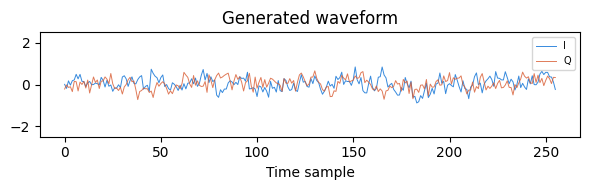

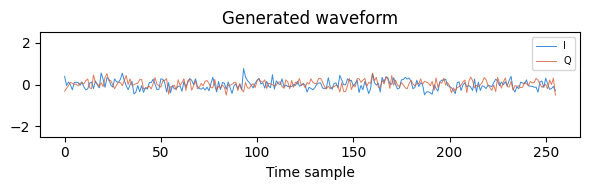

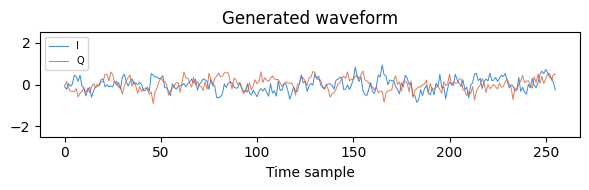

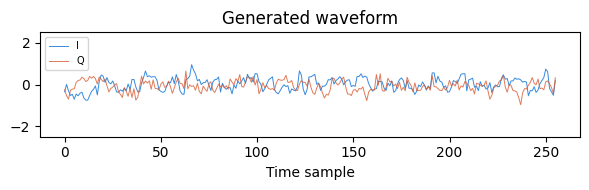

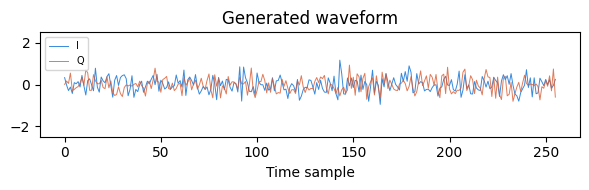

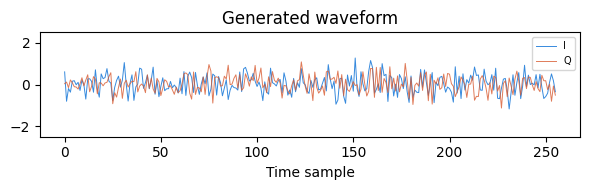

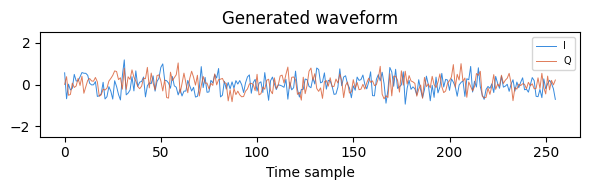

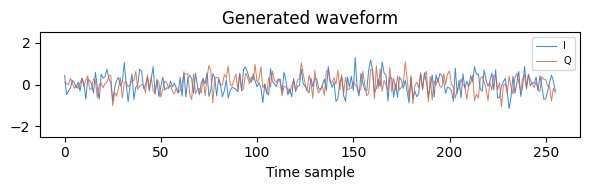

In [14]:
import shutil

# ── ambiguity loss ────────────────────────────────────────────────────────────
ambiguity_fn = AmbiguityLoss(
    n_doppler           = P2["n_doppler"],
    target_peak         = P2["target_peak"],
    zero_doppler_weight = P2["zero_doppler_w"],
    n_delays            = P2["n_delays"],
).to(DEVICE)

# ── load Phase 1 converged checkpoint ────────────────────────────────────────
G_p2 = Generator(latent_dim=P2["latent_dim"]).to(DEVICE)
C_p2 = Critic().to(DEVICE)

PHASE1_CKPT = "/kaggle/input/datasets/venugopalbattula/lpd-radar-checkpoints/phase1_final_epoch39.pt"
load_checkpoint(PHASE1_CKPT, G_p2, C_p2)
print(f"Loaded Phase 1 checkpoint ✓")

# ── verify ambiguity loss is active ──────────────────────────────────────────
with torch.no_grad():
    z_test = torch.randn(4, P2["latent_dim"], 1, device=DEVICE)
    y_test = next(iter(loader_gen))[0][:4].to(DEVICE)
    x_test = G_p2(z_test, y_test)

test_ambig = ambiguity_fn(x_test)
print(f"Ambiguity loss test: {test_ambig.item():.2f}  "
      f"{'✓ active' if test_ambig.item() > 0 else '✗ CHECK'}")

# ── override save_checkpoint to also backup to Output tab ─────────────────────
_original_save_p2 = save_checkpoint

def save_checkpoint(G, C, opt_G, opt_C, epoch, metrics, tag, ckpt_dir):
    path   = _original_save_p2(G, C, opt_G, opt_C, epoch, metrics, tag, ckpt_dir)
    backup = f"/kaggle/working/latest_ckpt_phase{tag.replace('phase','')[0]}.pt"
    shutil.copy(path, backup)
    return path

# ── run Phase 2 ───────────────────────────────────────────────────────────────
PHASE2_BEST = train(
    cfg          = P2,
    G            = G_p2,
    C            = C_p2,
    loader_gen   = loader_gen,
    run_name     = f"phase2-ambig-eta{P2['eta']}",
    ambiguity_fn = ambiguity_fn,
    resume_path  = None,   # already loaded above
)

print(f"\nPhase 2 best checkpoint: {PHASE2_BEST}")

In [15]:
import os, torch, shutil

# verify the Phase 2 checkpoint
path = "/kaggle/working/latest_ckpt_phase2.pt"

# check if it exists — if not, copy from checkpoints folder
if not os.path.exists(path):
    import glob
    files = sorted(glob.glob("/kaggle/working/checkpoints/ckpt_phase2*.pt"))
    if files:
        shutil.copy(files[-1], path)

ckpt = torch.load(path, map_location="cpu", weights_only=False)
print(f"Phase 2 checkpoint epoch : {ckpt['epoch']}")
print(f"Ambig loss               : {ckpt['metrics']['loss_ambig']:.2e}")
print(f"W-dist                   : {ckpt['metrics']['w_dist']:.4f}")
print(f"File size                : {os.path.getsize(path)/1e6:.1f} MB")

Phase 2 checkpoint epoch : 9
Ambig loss               : 2.83e+05
W-dist                   : 72.9229
File size                : 202.2 MB
